### Phase 4: Backtesting-Strategie
Wir plotten zunächst die Regime-Wahrscheinlichkeiten der Modelle sowie der tatsächlichen Modell-Signale.

Anschließend testen wir den Erfolg einer Investition in Abhängigkeit zum gewählten Modell und den unten beschriebenen Regeln.

*   **Regel:**
    *   Wenn Modell sagt "Bull": 100% Aktien (S&P 500).
    *   Wenn Modell sagt "Bear": 100% Bonds oder Cash.
*   **Transaktionskosten:** Integriere realistische Kosten (z.B. 0,1% pro Trade), da ML-Modelle oft zu nervös hin- und herschalten ("Churning").

In [1]:
import pandas as pd

# Daten aus dem data-Ordner laden
test_df = pd.read_parquet("../data/03_test_df_data.parquet")

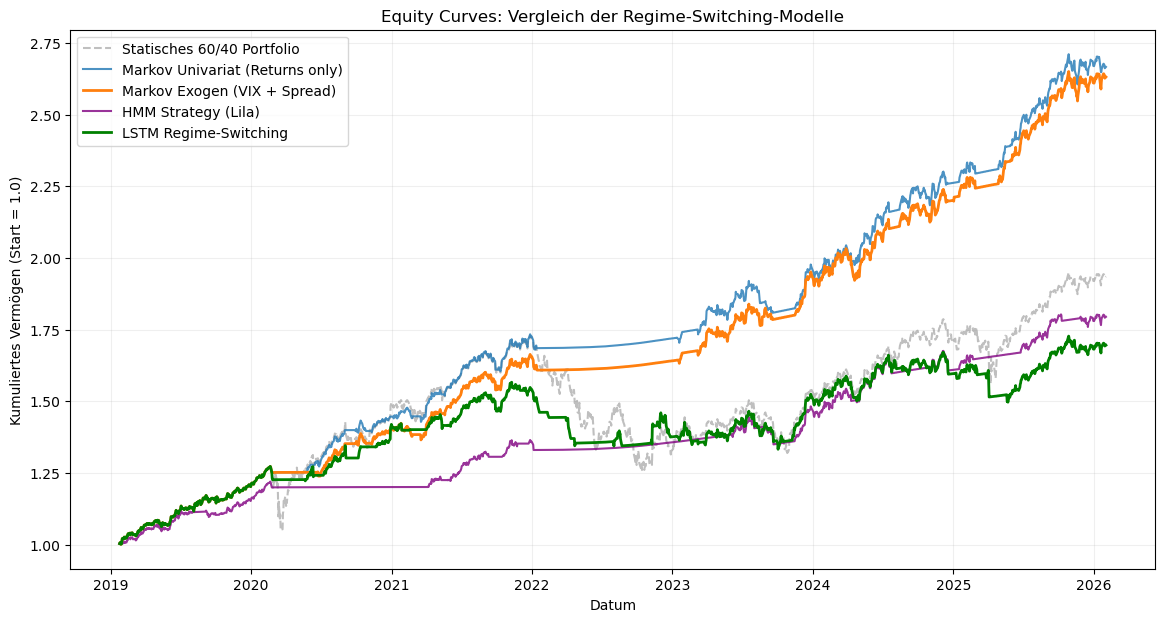

In [2]:
# --- 5. Erweitertes Backtesting (Vergleich aller Strategien) ---

import matplotlib.pyplot as plt
import numpy as np

def backtest(df, signal_col):
    """
    Berechnet die kumulierte Rendite einer Strategie.
    Bull (0): Investiert im 60/40 Portfolio
    Bear (1): Investiert im Geldmarkt (Cash_Returns)
    """
    # WICHTIG: Signal um 1 Tag verschieben! 
    # Wir handeln HEUTE basierend auf dem Signal, das GESTERN ABEND vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Kumulierte Rendite berechnen (Startwert 1.0)
    return (1 + strategy_returns).cumprod()

# Ergebnisse in ein neues DataFrame für den Vergleich schreiben
backtesting_results = pd.DataFrame(index=test_df.index)

# 1. Benchmark: Statisches Buy & Hold (60% Aktien / 40% Anleihen)
backtesting_results['Buy_Hold'] = (1 + test_df['Returns']).cumprod()

# 2. Strategie: Markov Univariat (Nur basierend auf Rendite-Statistik)
backtesting_results['MS_Univariate'] = backtest(test_df, 'MS_Univariate_Signal')

# 3. Strategie: Markov Exogen (Inklusive VIX & Yield Spread)
backtesting_results['MS_Exogenous'] = backtest(test_df, 'MS_Exo_Signal')

# 4. Strategie: LSTM-Regime (Deep Learning Vorhersage)
backtesting_results['LSTM_Regime'] = backtest(test_df, 'LSTM_Signal')

# 5. Strategie: HMM-Regime
backtesting_results['HMM_Based'] = backtest(test_df, 'HMM_Regime')

# --- Visualisierung ---
plt.figure(figsize=(14, 7))

# Buy & Hold als graue Basislinie
plt.plot(backtesting_results['Buy_Hold'], label='Statisches 60/40 Portfolio', color='gray', alpha=0.5, linestyle='--')

# Die aktiven Strategien
plt.plot(backtesting_results['MS_Univariate'], label='Markov Univariat (Returns only)', alpha=0.8)
plt.plot(backtesting_results['MS_Exogenous'], label='Markov Exogen (VIX + Spread)', linewidth=2)
plt.plot(backtesting_results['HMM_Based'], label='HMM Strategy (Lila)', color='purple', linewidth=1.5, alpha=0.8)
plt.plot(backtesting_results['LSTM_Regime'], label='LSTM Regime-Switching', linewidth=2, color='green')

plt.title("Equity Curves: Vergleich der Regime-Switching-Modelle")
plt.xlabel("Datum")
plt.ylabel("Kumuliertes Vermögen (Start = 1.0)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
# Equity Curve persistieren
plt.savefig('../assets/equity_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Wir erhalten in diesem Schritt neben df und test_df backtesting_results_df mit kumulierten Werten ---

In [3]:
# --- Performance & Drawdown Zusammenfassung ---

print("\n--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---")

summary_stats = []

for col in backtesting_results.columns:
    series = backtesting_results[col]
    
    # Finale Werte berechnen
    final_val = series.iloc[-1]
    total_ret = (final_val - 1) * 100
    
    # Max Drawdown berechnen
    roll_max = series.cummax()
    drawdown = series / roll_max - 1.0
    mdd = drawdown.min() * 100
    
    summary_stats.append({
        'Strategie': col,
        'Final Wealth': f"{final_val:.4f}",
        'Total Return': f"{total_ret:+.2f}%",
        'Max Drawdown': f"{mdd:.2f}%"
    })

# In DataFrame umwandeln
performance_summary_df = pd.DataFrame(summary_stats).set_index('Strategie')

# Als Markdown persistieren
performance_summary_df.to_markdown('../assets/performance_summary.md')

print("Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.")

# Im Notebook anzeigen
display(performance_summary_df)


--- PERFORMANCE & DRAWDOWN ZUSAMMENFASSUNG ---
Zusammenfassung erfolgreich unter ../assets/performance_summary.md gespeichert.


,Final Wealth,Total Return,Max Drawdown
Strategie,,,
Buy_Hold,1.9352,+93.52%,-27.10%
MS_Univariate,2.6662,+166.62%,-5.80%
MS_Exogenous,2.6312,+163.12%,-5.44%
LSTM_Regime,1.6955,+69.55%,-14.93%
HMM_Based,1.7944,+79.44%,-6.53%


In [4]:
output_path = "../data/04_backtesting_results_data.parquet"

# Speichern als Parquet
backtesting_results.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/04_backtesting_results_data.parquet gespeichert.
